In [1]:

# Get Dataset
!git clone https://github.com/SartajBhuvaji/Brain-Tumor-Classification-DataSet

Cloning into 'Brain-Tumor-Classification-DataSet'...
remote: Enumerating objects: 3039, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 3039 (delta 0), reused 0 (delta 0), pack-reused 3035 (from 1)
Receiving objects: 100% (3039/3039), 79.25 MiB | 34.56 MiB/s, done.


In [2]:

!pwd


/content


In [3]:
from keras.models import Sequential
from keras.layers import Activation, Dense, Flatten
from keras.optimizers import Adam
from keras.callbacks import TensorBoard, EarlyStopping
import keras.optimizers
from sklearn.metrics import classification_report
import keras.optimizers
from keras.applications import vgg16
import numpy as np
import random
import os
from tqdm import tqdm
import pickle
import cv2

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.
Path to dataset files: /kaggle/input/brain-tumor-classification-mri


Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.
Dataset Path: /kaggle/input/brain-tumor-classification-mri
Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
90/90 ━━━━━━━━━━━━━━━━━━━━ 50s 485ms/step - accuracy: 0.3732 - loss: 1.3279 - val_accuracy: 0.3299 - val_loss: 1.5862
Epoch 2/60
90/90 ━━━━━━━━━━━━━━━━━━━━ 24s 264ms/step - accuracy: 0.5658 - loss: 1.0090 - val_accuracy: 0.3706 - val_loss: 2.3044
Epoch 3/60
90/90 ━━━━━━━━━━━━━━━━━━━━ 24s 261ms/step - accuracy: 0.6606 - loss: 0.7990 - val_accuracy: 0.3604 - val_loss: 2.9607
Epoch 4/60
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 257ms/step - accuracy: 0.6909 - loss: 0.7131 - val_accuracy: 0.3706 - val_loss: 2.5483
Epoch 5/60
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 252ms/step - accuracy: 0.7067 - loss: 0.7083 - val_accuracy: 0.4086 - val_loss: 2.5004
Epoch 6/60
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 249ms/step - accuracy: 0.7426 - loss: 0.6193 - val_accuracy: 0.4036 - val_loss: 2.8540
Epoch 7/60
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 254ms/step - accuracy: 0.7572 - loss: 0.5717 - val_accuracy: 0.4010 - val_loss: 3.1259
Epoch 8/60
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 258ms/step - accuracy: 0.7645 - loss: 0.5705 - val_accu

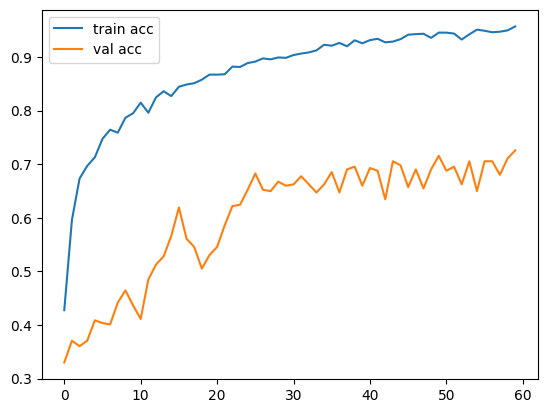

In [5]:
import kagglehub
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# ------------------------------------
# 1. DOWNLOAD DATASET
# ------------------------------------
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
print("Dataset Path:", path)

train_dir = path + "/Training"
test_dir = path + "/Testing"

# ------------------------------------
# 2. IMAGE GENERATORS
# ------------------------------------
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# ------------------------------------
# 3. CNN MODEL
# ------------------------------------
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4, activation='softmax')  # 4 classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ------------------------------------
# 4. TRAIN MODEL
# ------------------------------------
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=60
)

# ------------------------------------
# 5. PLOT ACCURACY
# ------------------------------------
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

# ------------------------------------
# 6. SAVE MODEL
# ------------------------------------
model.save("brain_tumor_cnn_model.h5")


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.7433 - loss: 4.8761
Test Loss: 5.3393
Test Accuracy: 0.7259

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       1.00      0.19      0.32       100
meningioma_tumor       0.75      0.94      0.83       115
        no_tumor       0.59      0.99      0.74       105
 pituitary_tumor       0.98      0.74      0.85        74

        accuracy                           0.73       394
       macro avg       0.83      0.72      0.69       394
    weighted avg       0.82      0.73      0.68       394



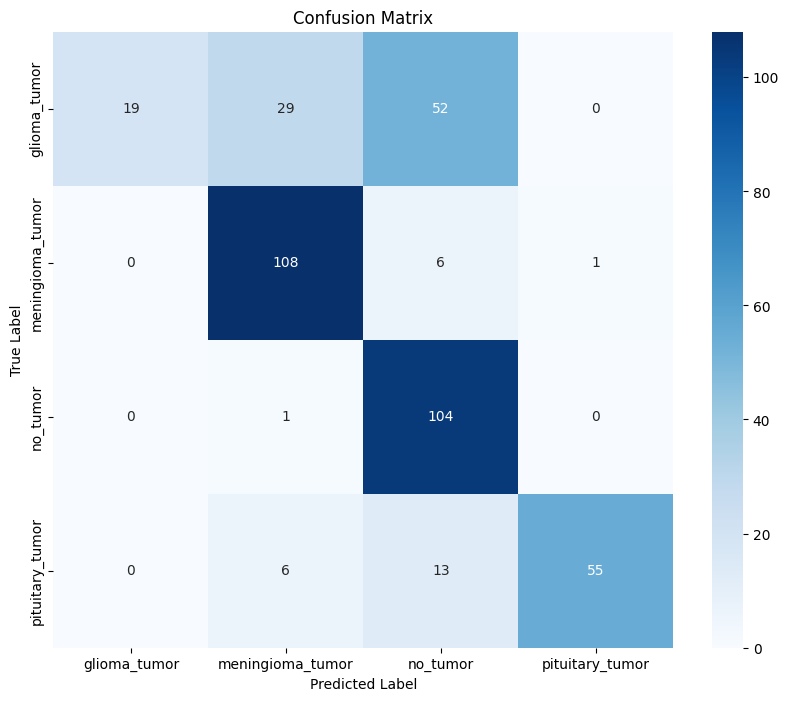

In [6]:
# 7. EVALUATE MODEL
loss, accuracy = model.evaluate(test_data)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions and true labels in the correct order
test_data.reset() # Reset the generator to ensure it starts from the beginning

all_predictions = []
all_true_labels = []

# Iterate through the test_data generator to get predictions and true labels
for i in range(len(test_data)):
    images, labels = test_data[i]
    preds = model.predict(images, verbose=0)
    all_predictions.extend(np.argmax(preds, axis=1))
    all_true_labels.extend(np.argmax(labels, axis=1)) # Assuming labels are one-hot encoded

predicted_classes = np.array(all_predictions)
true_classes = np.array(all_true_labels)

class_labels = list(test_data.class_indices.keys())

print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [7]:
import gradio as gr
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

# Load your saved model
model = tf.keras.models.load_model("brain_tumor_cnn_model.h5")

# Class names (order must match your t raining generator)
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]

def predict(img):
    # Resize image to match model input
    img = img.resize((150, 150))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    pred = model.predict(img_array)
    class_idx = np.argmax(pred)
    confidence = float(np.max(pred)) * 100

    return {
        "Predicted Class": CLASS_NAMES[class_idx],
        "Confidence (%)": round(confidence, 2)
    }

# Gradio UI
iface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.JSON(),
    title="Brain Tumor MRI Classifier (CNN)",
    description="Upload an MRI image to classify it into Glioma, Meningioma, No Tumor, or Pituitary."
)

iface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://46322f69d94a7f52c4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [8]:
pip install flask tensorflow pillow numpy


In [ ]:
from flask import Flask, request, jsonify
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
from PIL import Image
import io

# Load your saved model at app startup
model = tf.keras.models.load_model("brain_tumor_cnn_model.h5")

# Class names (order must match your training generator)
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]

# Initialize Flask app
app = Flask(__name__)

def predict(img):
    # Resize image to match model input
    img = img.resize((150, 150))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    pred = model.predict(img_array)
    class_idx = np.argmax(pred)
    confidence = float(np.max(pred)) * 100

    return {
        "Predicted Class": CLASS_NAMES[class_idx],
        "Confidence (%)": round(confidence, 2)
    }

@app.route('/')
def home():
    return '''
        <h1>Brain Tumor MRI Classifier</h1>
        <p>Upload an MRI image to classify it into Glioma, Meningioma, No Tumor, or Pituitary.</p>
    '''

@app.route('/predict', methods=['POST'])
def upload_image():
    if 'file' not in request.files:
        return jsonify({"error": "No file part"})

    file = request.files['file']
    if file.filename == '':
        return jsonify({"error": "No selected file"})

    try:
        img = Image.open(file.stream)
        result = predict(img)
        return jsonify(result)
    except Exception as e:
        return jsonify({"error": str(e)})

if __name__ == '__main__':
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


In [9]:
pip install fastapi uvicorn tensorflow pillow numpy


In [ ]:
from fastapi import FastAPI, File, UploadFile
from pydantic import BaseModel
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
from PIL import Image
import io
from fastapi.responses import JSONResponse

# Load your saved model at app startup
model = tf.keras.models.load_model("brain_tumor_cnn_model.h5")

# Class names (order must match your training generator)
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]

# Initialize FastAPI app
app = FastAPI()

class PredictionResponse(BaseModel):
    Predicted_Class: str
    Confidence: float

def predict(img: Image.Image):
    # Resize image to match model input
    img = img.resize((150, 150))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    pred = model.predict(img_array)
    class_idx = np.argmax(pred)
    confidence = float(np.max(pred)) * 100

    return {
        "Predicted Class": CLASS_NAMES[class_idx],
        "Confidence (%)": round(confidence, 2)
    }

@app.get("/")
def home():
    return {"message": "Brain Tumor MRI Classifier API. Use POST /predict to upload an image for classification."}

@app.post("/predict", response_model=PredictionResponse)
async def upload_image(file: UploadFile = File(...)):
    try:
        # Read the uploaded image file
        img = Image.open(io.BytesIO(await file.read()))
        result = predict(img)
        return JSONResponse(content=result)
    except Exception as e:
        return JSONResponse(content={"error": str(e)}, status_code=400)

if __name__ == '__main__':
    import uvicorn
    uvicorn.run(app, host="127.0.0.1", port=8000)
